In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


In [3]:
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

df_train = pd.read_csv("../adult/adult.data", header=None, names=column_names)
df_test = pd.read_csv('../adult/adult.test', header=None, names=column_names, skiprows=1)

df_test['income'] = df_test['income'].str.strip().str.rstrip('.')
df_test['income'] = (df_test['income'] == ">50K").astype(int)

df_train['income'] = df_train['income'].str.strip().str.rstrip('.')
df_train['income'] = (df_train['income'] == ">50K").astype(int)

X_train = pd.get_dummies(df_train.drop("income", axis=1))
y_train = df_train["income"]

X_test = pd.get_dummies(df_test.drop("income", axis=1))
y_test = df_test["income"]

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=50))
])

param_grid = {
    'mlp__hidden_layer_sizes': [(32,), (64, 32), (128, 64, 32)],
    'mlp__activation': ['relu', 'tanh', 'logistic'],
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__solver': ['adam', 'sgd'],
}

grid = GridSearchCV(pipe, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)

best_model = grid.best_estimator_

y_train_pred = best_model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)  # <-- compute F1

print("Training accuracy:", train_acc)
print("Training F1 score:", train_f1)

y_test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)    # <-- compute F1

print("Testing accuracy:", test_acc)
print("Testing F1 score:", test_f1)

Best parameters: {'mlp__activation': 'logistic', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (64, 32), 'mlp__solver': 'adam'}
Training accuracy: 0.8681551549399589
Training F1 score: 0.7082172228641338
Testing accuracy: 0.8546772311283091
Testing F1 score: 0.6702898550724637


In [4]:
from sklearn.utils.class_weight import compute_sample_weight

In [5]:
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

df_train = pd.read_csv("../adult/adult.data", header=None, names=column_names)
df_test = pd.read_csv('../adult/adult.test', header=None, names=column_names, skiprows=1)

df_test['income'] = df_test['income'].str.strip().str.rstrip('.')
df_test['income'] = (df_test['income'] == ">50K").astype(int)

df_train['income'] = df_train['income'].str.strip().str.rstrip('.')
df_train['income'] = (df_train['income'] == ">50K").astype(int)

X_train = pd.get_dummies(df_train.drop("income", axis=1))
y_train = df_train["income"]

X_test = pd.get_dummies(df_test.drop("income", axis=1))
y_test = df_test["income"]

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


pipe = Pipeline([
    ('mlp', MLPClassifier(max_iter=50, random_state=42))
])

param_grid = {
    'mlp__hidden_layer_sizes': [(32,), (64, 32), (128, 64, 32)],
    'mlp__activation': ['relu', 'tanh', 'logistic'],
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__solver': ['adam', 'sgd'],
}

grid = GridSearchCV(pipe, param_grid, cv=3, scoring='accuracy', n_jobs=-1)


sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Fit GridSearchCV with sample weights
grid.fit(X_train, y_train, mlp__sample_weight=sample_weights)


best_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

# Training metrics
y_train_pred = best_model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
print("\nTraining accuracy:", train_acc)
print("Training F1 score:", train_f1)

# Testing metrics
y_test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
print("\nTesting accuracy:", test_acc)
print("Testing F1 score:", test_f1)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best parameters: {'mlp__activation': 'logistic', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (32,), 'mlp__solver': 'adam'}
Best CV accuracy: 0.8156077170741556

Training accuracy: 0.8270937624765824
Training F1 score: 0.7078663345786633

Testing accuracy: 0.8143848657944843
Testing F1 score: 0.6810217437196537


In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
import torch
import torch.nn as nn
import torch.optim as optim
from skorch import NeuralNetClassifier

column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

df = pd.read_csv("../adult/adult.data", header=None, names=column_names)
df['income'] = (df['income'].str.strip() == '>50K').astype(int)

X = pd.get_dummies(df.drop('income', axis=1))
y = df['income'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

n_pos = np.sum(y_train)
n_neg = y_train.shape[0] - n_pos
pos_weight = n_neg / n_pos
pos_weight_tensor = torch.tensor([pos_weight], dtype=torch.float32)

class MLPModule(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, activation='sigmoid'):
        super().__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, 1)
        if activation == 'sigmoid':
            self.act = nn.Sigmoid()
        elif activation == 'tanh':
            self.act = nn.Tanh()
        elif activation == 'relu':
            self.act = nn.ReLU()
        else:
            raise ValueError("Invalid activation")

    def forward(self, X):
        X = self.act(self.hidden(X))
        X = self.output(X)  # raw logits for BCEWithLogitsLoss
        return X


net = NeuralNetClassifier(
    MLPModule,
    module__input_dim=X_train.shape[1],
    module__hidden_dim=32,
    module__activation='sigmoid',   # logistic
    criterion=nn.BCEWithLogitsLoss,
    criterion__pos_weight=pos_weight_tensor,
    optimizer=optim.Adam,
    optimizer__weight_decay=0.0001,  # alpha
    max_epochs=50,
    lr=0.001,
    batch_size=64,
    iterator_train__shuffle=True,
    verbose=1,
    train_split=None 
)

param_grid = {
    'module__hidden_dim': [32, 64, 128],         
    'module__activation': ['relu', 'tanh', 'sigmoid'],  
    'optimizer__weight_decay': [0.0001, 0.001, 0.01], 
    'optimizer': [torch.optim.Adam, torch.optim.SGD],  
}

gs = GridSearchCV(net, param_grid, cv=3, scoring='accuracy', refit=True)
gs.fit(X_train.astype(np.float32), y_train.astype(np.float32).reshape(-1, 1))

best_model = gs.best_estimator_
y_train_pred = best_model.predict(X_train.astype(np.float32))
y_test_pred = best_model.predict(X_test.astype(np.float32))

print("Best parameters:", gs.best_params_)
print("Best CV accuracy:", gs.best_score_)

print("\nTraining accuracy:", accuracy_score(y_train, y_train_pred))
print("Training F1 score:", f1_score(y_train, y_train_pred))
print("Testing accuracy:", accuracy_score(y_test, y_test_pred))
print("Testing F1 score:", f1_score(y_test, y_test_pred))


  epoch    train_loss     dur
-------  ------------  ------
      1        0.6986  0.1584
      2        0.5869  0.1526
      3        0.5694  0.1515
      4        0.5585  0.1526
      5        0.5506  0.1539
      6        0.5450  0.1518
      7        0.5404  0.1544
      8        0.5348  0.1565
      9        0.5300  0.1532
     10        0.5266  0.1539
     11        0.5216  0.1529
     12        0.5175  0.1565
     13        0.5132  0.1622
     14        0.5100  0.1532
     15        0.5070  0.1515
     16        0.5046  0.1535
     17        0.5019  0.1544
     18        0.4976  0.1558
     19        0.4957  0.1521
     20        0.4949  0.1539
     21        0.4917  0.1578
     22        0.4893  0.1566
     23        0.4870  0.1531
     24        0.4855  0.1515
     25        0.4835  0.1518
     26        0.4826  0.1515
     27        0.4798  0.1507
     28        0.4792  0.1521
     29        0.4774  0.1508
     30        0.4766  0.1513
     31        0.4737  0.1514
     32   

**sklearn MLPLearner**
```
Best parameters: {'mlp__activation': 'logistic', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (64, 32), 'mlp__solver': 'adam'}

Training accuracy: 0.8681551549399589
Training F1 score: 0.7082172228641338

Testing accuracy: 0.8546772311283091
Testing F1 score: 0.6702898550724637
```

**sklearn with weights**
```
Best parameters: {'mlp__activation': 'logistic', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (32,), 'mlp__solver': 'adam'}

Best CV accuracy: 0.8156077170741556

Training accuracy: 0.8270937624765824
Training F1 score: 0.7078663345786633

Testing accuracy: 0.8143848657944843
Testing F1 score: 0.6810217437196537
```

**Pytorch + Skorch**
```
Best parameters: {'module__activation': 'sigmoid', 'module__hidden_dim': 128, 'optimizer': <class 'torch.optim.adam.Adam'>, 'optimizer__weight_decay': 0.0001}
Best CV accuracy: 0.8174527134016006

Training accuracy: 0.8170684889434889
Training F1 score: 0.7060637838504719
Testing accuracy: 0.8034699831107017
Testing F1 score: 0.6839506172839506
```

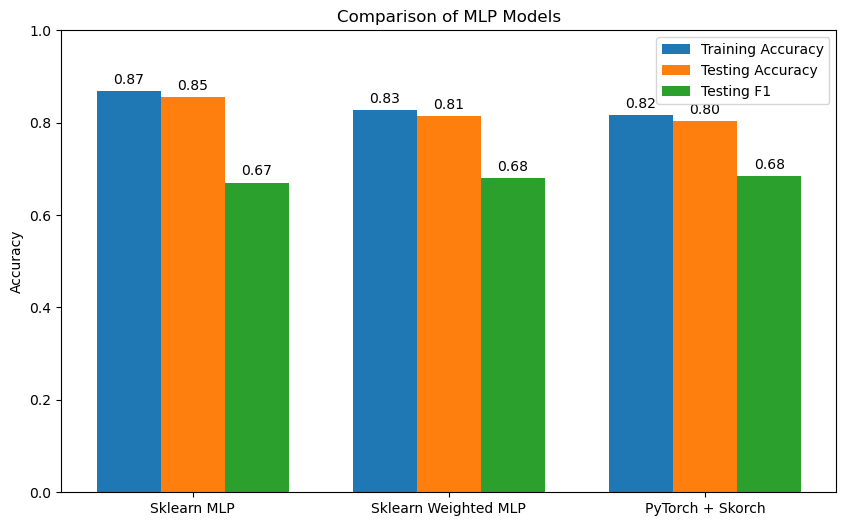

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Define the models and their metrics
models = ['Sklearn MLP', 'Sklearn Weighted MLP', 'PyTorch + Skorch']
train_acc = [0.8681551549399589, 0.8270937624765824, 0.8170684889434889]
test_acc = [0.8546772311283091, 0.8143848657944843, 0.8034699831107017]
test_f1 = [0.6702898550724637, 0.6810217437196537, 0.6839506172839506]

x = np.arange(len(models))  # label locations
width = 0.25  # width of the bars

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - width, train_acc, width, label='Training Accuracy')
rects2 = ax.bar(x, test_acc, width, label='Testing Accuracy')
rects3 = ax.bar(x + width, test_f1, width, label='Testing F1')

# Labels and titles
ax.set_ylabel('Accuracy')
ax.set_title('Comparison of MLP Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)  # scale from 0 to 1
ax.legend()

# Add value labels on top of bars
for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()


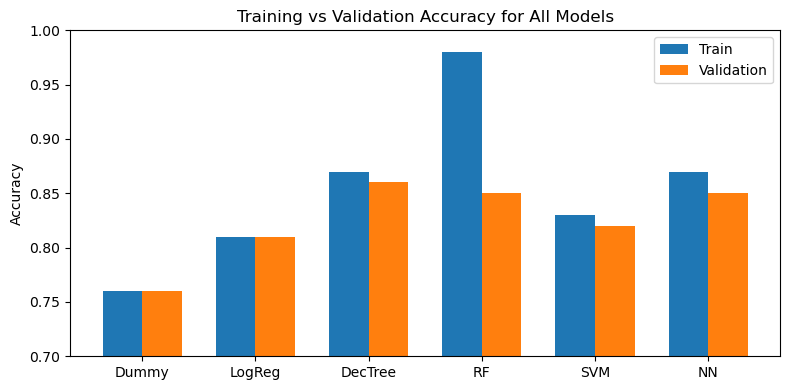

In [14]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Dummy", "LogReg", "DecTree", "RF", "SVM", "NN"]
train_scores = [0.76, 0.81, 0.87, 0.98, 0.83, 0.87]      # replace with your values
val_scores   = [0.76, 0.81, 0.86, 0.85, 0.82, 0.85]      # CV means

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,4))
plt.bar(x - width/2, train_scores, width, label="Train")
plt.bar(x + width/2, val_scores, width, label="Validation")

plt.ylabel("Accuracy")
plt.ylim(0.7, 1.0)
plt.xticks(x, models)
plt.title("Training vs Validation Accuracy for All Models")
plt.legend()
plt.tight_layout()
plt.show()